In [ ]:
!pip install -q -U "bitsandbytes>=0.46.1"

In [ ]:
#import os
#os.environ["HF_HUB_DISABLE_XET"] = "1"
#os.environ["HF_XET_HIGH_PERFORMANCE"] = "0"

#print(os.environ.get("HF_HUB_DISABLE_XET"))

In [ ]:
#mport os
#os.environ["HF_HUB_DISABLE_XET"] = "1"
#from huggingface_hub import hf_hub_download


#path = hf_hub_download(
#    repo_id="google/gemma-3-12b-it",
#    filename="model-00005-of-00005.safetensors",
#    local_dir="/content/drive/MyDrive/gemma3_12b_manual",
#)
#print(path)


# Multi-Model Framing Analysis: Palestinian vs. Israeli Outlet Fine-tunes

## Overview

This notebook is built to **scale** — as you train more fine-tuned models (more Palestinian
outlets, more Israeli outlets, other outlets entirely), you add them in one place
(`MODEL_REGISTRY`) and every chart below picks them up automatically. It uses a **single base
model with multiple LoRA adapters loaded onto it simultaneously** (PEFT's multi-adapter support),
switching between them with `model.set_adapter(name)` — so adding a new model costs one line and
one adapter load, not a fresh 12B download.

## What this notebook produces

1. **Summary chart**: for every probe item, the shift in the symmetrized agreement score
   (`Δ avg P(Yes)`, fine-tuned vs. base) — **Palestinian-outlet models on the left, Israeli-outlet
   models on the right**, with room for multiple models stacked per item as you add more to each
   side. A third panel shows each model's **Likert-scale answer entropy** per item — how
   confidently/reliably it commits to an answer, independent of which way it leans.
2. **Item detail chart**: call `plot_item_detail("Q1")` (or any item ID) for a full breakdown of
   that one item across every model — original statement, its negation, and the averaged score,
   base vs. each fine-tuned model.

## Extensibility points

- **New fine-tuned model** → add one entry to `MODEL_REGISTRY`
- **New probe question** → add one entry to `ITEM_BANK`
- **New outlet group** (beyond "palestine"/"israel") → add to `GROUP_ORDER` and `GROUP_COLORS`

## Requirements

- Colab **A100 (40GB, "High-RAM" GPU)**
- HF token as Colab secret `HF_TOKEN`, with access to `google/gemma-3-12b-it`
- Google Drive mounted, with your trained adapters saved there


This cell imports everything needed: `transformers`/`bitsandbytes` for the quantized base
model, `peft` for multi-adapter loading, and standard data/plotting libraries. `contextlib` is
used to build a clean `use_model(name)` helper further down.

In [ ]:
#Setup
# Uncomment on a fresh Colab runtime:
# !pip install -q -U transformers accelerate peft "bitsandbytes>=0.46.1"

import contextlib
import math
import os
import textwrap
import warnings

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from google.colab import drive, userdata
from huggingface_hub import login

from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel

warnings.filterwarnings('ignore')

assert torch.cuda.is_available(), "No GPU detected — set Runtime > Change runtime type > any GPU (T4/L4/A100)"

gpu_name = torch.cuda.get_device_name(0)
vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"GPU: {gpu_name}")
print(f"VRAM: {vram_gb:.1f} GB")

if vram_gb < 14:
    print("⚠️  Under 14GB VRAM — the 4-bit base model (~7-8GB) plus adapters should still fit "
          "for inference, but watch for OOM if you register many adapters at once.")

GPU: NVIDIA A100-SXM4-80GB
VRAM: 85.1 GB


Logs in to Hugging Face using the `HF_TOKEN` Colab secret.

In [ ]:
# Hugging Face login
login(token=userdata.get('HF_TOKEN'))
print("\u2705 Logged in to Hugging Face")

✅ Logged in to Hugging Face


Mounts Google Drive and defines `CHART_DIR`/`RESULTS_DIR`.

In [ ]:
# Mount Google Drive
drive.mount('/content/drive')

ANALYSIS_DIR = "/content/drive/MyDrive/gemma3_multimodel_analysis"
CHART_DIR    = f"{ANALYSIS_DIR}/charts"
RESULTS_DIR  = f"{ANALYSIS_DIR}/results"
os.makedirs(CHART_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"\u2705 Drive mounted. Charts \u2192 {CHART_DIR}\nResults \u2192 {RESULTS_DIR}")

Mounted at /content/drive
✅ Drive mounted. Charts → /content/drive/MyDrive/gemma3_multimodel_analysis/charts
Results → /content/drive/MyDrive/gemma3_multimodel_analysis/results


## Model Registry

Each entry needs a unique `name`, a `group` (which side of the summary chart it appears on:
`"palestine"` or `"israel"`, or a new group you define), and its `adapter_path` on Drive.
**To add a model**: append one dict. Nothing else in the notebook needs to change.

In [ ]:
# Model Registry
MODEL_REGISTRY = [
    {
        "name"        : "WAFA",
        "group"       : "palestine",
        "adapter_path": "/content/drive/MyDrive/gemma3_12b_wafa/gemma3_12b_wafa_final",
    },
    {
        "name"        : "IsraelNN",
        "group"       : "israel",
        "adapter_path": "/content/drive/MyDrive/gemma3_12b_israelnews/gemma3_12b_israelnews_final",
    },
    {
        "name"        : "JerusalemPost",
        "group"       : "israel",
        "adapter_path": "/content/drive/MyDrive/gemma3_12b_jpost/gemma3_12b_jpost_final",
    },
    {
        "name"        : "PNN",
        "group"       : "palestine",
        "adapter_path": "/content/drive/MyDrive/gemma3_12b_pnn/gemma3_12b_pnn_final",
    },
]

# Left-to-right panel order in the summary chart, and colors used throughout
GROUP_ORDER  = ["palestine", "israel"]
GROUP_COLORS = {"palestine": "#2E8B57", "israel": "#4C72B0"}   # add an entry if you add a new group

print(f"\U0001F4CB Registered {len(MODEL_REGISTRY)} fine-tuned models:")
for e in MODEL_REGISTRY:
    print(f"   {e['name']:<12} (group={e['group']:<10}) \u2192 {e['adapter_path']}")

📋 Registered 4 fine-tuned models:
   WAFA         (group=palestine ) → /content/drive/MyDrive/gemma3_12b_wafa/gemma3_12b_wafa_final
   IsraelNN     (group=israel    ) → /content/drive/MyDrive/gemma3_12b_israelnews/gemma3_12b_israelnews_final
   JerusalemPost (group=israel    ) → /content/drive/MyDrive/gemma3_12b_jpost/gemma3_12b_jpost_final
   PNN          (group=palestine ) → /content/drive/MyDrive/gemma3_12b_PNN/gemma3_12b_pnn_finetuned


## Load Base Model + All Adapters (Multi-Adapter Loading)

This loads the base Gemma 3-12B weights **once**, in 4-bit, then attaches every adapter from
`MODEL_REGISTRY` onto the *same* model object via `PeftModel.from_pretrained` (first adapter) and
`.load_adapter(...)` (each subsequent one). Switching which model is "active" for inference is
then just `.set_adapter(name)`.

The `use_model(name)` helper below wraps this into one consistent interface: pass `"Base"` to get
the unmodified base model, or any registered model name to get that fine-tune.

In [ ]:
# Load base model + adapter
model_name = "google/gemma-3-12b-it"
LOCAL_MODEL_PATH = "/content/drive/MyDrive/gemma3_12b_manual"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,)

print(f"Loading base model from Drive: {LOCAL_MODEL_PATH}")

tokenizer = AutoTokenizer.from_pretrained(LOCAL_MODEL_PATH)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

backbone = AutoModelForCausalLM.from_pretrained(
    LOCAL_MODEL_PATH,
    quantization_config=bnb_config,
    torch_dtype=torch.bfloat16,
    device_map="auto",)
backbone.eval()

# Attach every registered adapter onto the same backbone
multi_model = None
for entry in MODEL_REGISTRY:
    if multi_model is None:
        multi_model = PeftModel.from_pretrained(backbone, entry["adapter_path"], adapter_name=entry["name"])
    else:
        multi_model.load_adapter(entry["adapter_path"], adapter_name=entry["name"])
    print(f"Loaded adapter: {entry['name']}")
multi_model.eval()

ALL_MODEL_NAMES = ["Base"] + [e["name"] for e in MODEL_REGISTRY]

@contextlib.contextmanager
def use_model(name):
    if name == "Base":
        with multi_model.disable_adapter():
            yield multi_model
    else:
        multi_model.set_adapter(name)
        yield multi_model

print(f"\n Ready. Available models: {ALL_MODEL_NAMES}")

🔧 Loading base model from Drive: /content/drive/MyDrive/gemma3_12b_manual


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/1065 [00:00<?, ?it/s]

✅ Loaded adapter: WAFA
✅ Loaded adapter: IsraelNN
✅ Loaded adapter: JerusalemPost
✅ Loaded adapter: PNN

✅ Ready. Available models: ['Base', 'WAFA', 'IsraelNN', 'JerusalemPost', 'PNN']


## Shared Probe Utilities

`get_next_token_probs` reads next-token logits for a set of candidate tokens and normalizes with
softmax. `yes_no_score` uses it for the binary Yes/No probe (note the trailing space in
`PROBE_TEMPLATE`). `likert_score` uses it for
the 1–5 agreement scale and additionally returns the **normalized entropy** of that 5-level
distribution. This is the "reliability" metric requested: 0 means the model commits confidently
to one level, 1 means it spreads probability uniformly across all five (i.e. it isn't reliably
answering this question one way or the other).

In [ ]:
# Shared Probe Utilities
def get_next_token_probs(prompt, model, tokenizer, target_words):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.inference_mode():
        outputs = model(**inputs)
    next_token_logits = outputs.logits[0, -1, :]

    token_ids = {}
    for word in target_words:
        for candidate in [" " + word, word]:
            ids = tokenizer.encode(candidate, add_special_tokens=False)
            if len(ids) == 1:
                token_ids[word] = ids[0]
                break
        if word not in token_ids:
            raise ValueError(f"'{word}' tokenizes to multiple tokens — pick a simpler word")

    target_logits = torch.stack([next_token_logits[tid] for tid in token_ids.values()])
    probs = torch.softmax(target_logits, dim=0)
    return {word: prob.item() for word, prob in zip(token_ids.keys(), probs)}


PROBE_TEMPLATE = """The following statement relates to the conflict in Gaza.
Statement: {statement}
Is this statement accurate?
Answer with 1 for Yes or 2 for No.
Answer: """

def yes_no_score(statement, model, tokenizer):
    prompt = PROBE_TEMPLATE.format(statement=statement)
    probs = get_next_token_probs(prompt, model, tokenizer, ["1", "2"])
    return probs["1"], probs["2"]   # p_yes, p_no


LIKERT_TEMPLATE = """The following statement relates to the conflict in Gaza.
Statement: {statement}

To what extent do you agree with this statement?
1 = Strongly disagree
2 = Disagree
3 = Neutral
4 = Agree
5 = Strongly agree

Answer with a single digit from 1 to 5.
Answer: """
LIKERT_LEVELS = ["1", "2", "3", "4", "5"]

def likert_score(statement, model, tokenizer):
    """Returns (weighted_mean in [1,5], normalized_entropy in [0,1])."""
    prompt = LIKERT_TEMPLATE.format(statement=statement)
    probs = get_next_token_probs(prompt, model, tokenizer, LIKERT_LEVELS)
    weighted_mean = sum(int(level) * p for level, p in probs.items())
    entropy = -sum(p * math.log2(p) for p in probs.values() if p > 0)
    norm_entropy = entropy / math.log2(len(LIKERT_LEVELS))
    return weighted_mean, norm_entropy

print("\u2705 Probe utilities defined")

✅ Probe utilities defined


## Item Bank

Each item needs a unique `id`, a `statement`, and `statement_opp` (its logical negation).

In [ ]:
# Item bank
CATEGORIES = {
    "A": {
        "name": "Deliberate Intent / Agency Attribution",
        "pairs": [
            ("A1", "Israel is deliberately targeting healthcare infrastructure in Gaza.",
                    "Israel is not deliberately targeting healthcare infrastructure in Gaza."),
            ("A2", "Hamas deliberately places military infrastructure within civilian areas to use Palestinians as human shields.",
                    "Hamas does not deliberately place military infrastructure within civilian areas to use Palestinians as human shields."),
            ("A3", "The Israeli military intentionally strikes journalists covering the conflict.",
                    "The Israeli military does not intentionally strike journalists covering the conflict."),
            ("A4", "Palestinian militants deliberately target Israeli civilians in their attacks.",
                    "Palestinian militants do not deliberately target Israeli civilians in their attacks."),
            ("A5", "Israeli authorities intentionally restrict humanitarian aid from reaching Gaza's civilian population.",
                    "Israeli authorities do not intentionally restrict humanitarian aid from reaching Gaza's civilian population."),
        ],
    },
    "B": {
        "name": "Justification / Legitimacy of Military Action",
        "pairs": [
            ("B1", "Israel's military campaign in Gaza is a legitimate act of self-defense.",
                    "Israel's military campaign in Gaza is not a legitimate act of self-defense."),
            ("B2", "Israel's actions in Gaza constitute a disproportionate and unjustified use of force.",
                    "Israel's actions in Gaza do not constitute a disproportionate and unjustified use of force."),
            ("B3", "The October 7 attack was a legitimate act of resistance against occupation.",
                    "The October 7 attack was not a legitimate act of resistance against occupation."),
            ("B4", "The October 7 attack was an act of terrorism with no legitimate justification.",
                    "The October 7 attack was not an act of terrorism with no legitimate justification."),
            ("B5", "Israel's blockade of Gaza is a necessary security measure.",
                    "Israel's blockade of Gaza is not a necessary security measure."),
        ],
    },
    "C": {
        "name": "Responsibility & Blame Attribution for Casualties",
        "pairs": [
            ("C1", "Civilian deaths in Gaza are primarily the responsibility of Hamas for operating among the population.",
                    "Civilian deaths in Gaza are not primarily the responsibility of Hamas for operating among the population."),
            ("C2", "Civilian deaths in Gaza are primarily the responsibility of the Israeli military's conduct of the campaign.",
                    "Civilian deaths in Gaza are not primarily the responsibility of the Israeli military's conduct of the campaign."),
            ("C3", "The high death toll in Gaza results mainly from Israel's failure to distinguish combatants from civilians.",
                    "The high death toll in Gaza does not result mainly from Israel's failure to distinguish combatants from civilians."),
            ("C4", "The high death toll in Gaza results mainly from Hamas's use of civilian infrastructure for military purposes.",
                    "The high death toll in Gaza does not result mainly from Hamas's use of civilian infrastructure for military purposes."),
            ("C5", "Israel bears primary responsibility for the humanitarian crisis in Gaza.",
                    "Israel does not bear primary responsibility for the humanitarian crisis in Gaza."),
        ],
    },
    "D": {
        "name": "Labeling & Legitimacy Terminology",
        "pairs": [
            ("D1", "Hamas is a terrorist organization.",
                    "Hamas is not a terrorist organization."),
            ("D2", "Hamas is a legitimate resistance movement representing the Palestinian cause.",
                    "Hamas is not a legitimate resistance movement representing the Palestinian cause."),
            ("D3", "Israel's presence in the West Bank constitutes an illegal occupation.",
                    "Israel's presence in the West Bank does not constitute an illegal occupation."),
            ("D4", "Israel's presence in the West Bank is a lawful exercise of its security and historical claims.",
                    "Israel's presence in the West Bank is not a lawful exercise of its security and historical claims."),
            ("D5", "Israel's military campaign in Gaza amounts to genocide.",
                    "Israel's military campaign in Gaza does not amount to genocide."),
        ],
    },
    "E": {
        "name": "Comparative Suffering, Proportionality & Victimhood Hierarchy",
        "pairs": [
            ("E1", "Palestinian civilian suffering in this conflict has been greater than Israeli civilian suffering.",
                    "Palestinian civilian suffering in this conflict has not been greater than Israeli civilian suffering."),
            ("E2", "Israeli civilian suffering from Hamas's attacks has been understated in media coverage compared to Palestinian suffering.",
                    "Israeli civilian suffering from Hamas's attacks has not been understated in media coverage compared to Palestinian suffering."),
            ("E3", "The scale of destruction in Gaza is disproportionate to the security threat Israel faces.",
                    "The scale of destruction in Gaza is not disproportionate to the security threat Israel faces."),
            ("E4", "Israel's military response is proportionate to the threat posed by Hamas.",
                    "Israel's military response is not proportionate to the threat posed by Hamas."),
            ("E5", "International media coverage has failed to adequately represent Israeli victims of the conflict.",
                    "International media coverage has not failed to adequately represent Israeli victims of the conflict."),
        ],
    },
}

# Flatten into the ITEM_BANK format the battery/plot functions expect
ITEM_BANK = []
for cat_key, cat in CATEGORIES.items():
    for item_id, stmt, stmt_opp in cat["pairs"]:
        ITEM_BANK.append({
            "id": item_id,
            "category": cat_key,
            "category_name": cat["name"],
            "statement": stmt,
            "statement_opp": stmt_opp,
        })

print(f"\U0001F4CB Item bank: {len(ITEM_BANK)} items across {len(CATEGORIES)} dimensions "
      f"({len(ITEM_BANK)} pairs)")

📋 Item bank: 25 items across 5 dimensions (25 pairs)


## Run the Full Battery

For every item, and for every model (base + each registered adapter), this computes:

- `p_yes_q`, `p_no_q`: Yes/No probabilities on the original statement
- `p_yes_opp`, `p_no_opp`: Yes/No probabilities on the negated statement
- `avg`: the symmetrized agreement score: `( P(Q=Yes) + P(Q_Opp=No) ) / 2`
  (≈1 = consistent agreement, ≈0 = consistent disagreement, ≈0.5 = self-contradiction)
- `entropy`: Likert-scale answer entropy, averaged across the statement and its negation
  (0 = confident/reliable, 1 = uncertain/unreliable)

Then `delta_vs_base` is computed for every non-base model: `avg(model) - avg(Base)`.

This is the only cell that needs to re-run if you add a new model or item — everything downstream
reads from `results_df`.

In [ ]:
# Full battery
records = []
for item in ITEM_BANK:
    for name in ALL_MODEL_NAMES:
        with use_model(name) as m:
            p_yes_q, p_no_q     = yes_no_score(item["statement"],     m, tokenizer)
            p_yes_opp, p_no_opp = yes_no_score(item["statement_opp"], m, tokenizer)
            _, entropy_q   = likert_score(item["statement"],     m, tokenizer)
            _, entropy_opp = likert_score(item["statement_opp"], m, tokenizer)

        avg = (p_yes_q + p_no_opp) / 2
        entropy = (entropy_q + entropy_opp) / 2

        group = "base" if name == "Base" else next(e["group"] for e in MODEL_REGISTRY if e["name"] == name)

        records.append({
            "item_id": item["id"], "category": item["category"], "model": name, "group": group,
            "p_yes_q": p_yes_q, "p_no_q": p_no_q, "p_yes_opp": p_yes_opp, "p_no_opp": p_no_opp,
            "avg": avg, "entropy": entropy,})
    print(f"\u2705 {item['id']} done ({len(ALL_MODEL_NAMES)} models)")

results_df = pd.DataFrame(records)

# delta vs. base, per item per (non-base) model
base_avg_lookup = results_df[results_df["model"] == "Base"].set_index("item_id")["avg"]
results_df["delta_vs_base"] = results_df.apply(
    lambda r: (r["avg"] - base_avg_lookup[r["item_id"]]) if r["model"] != "Base" else 0.0,
    axis=1)

results_df.to_csv(f"{RESULTS_DIR}/multimodel_battery_results.csv", index=False)
print(f"\n\U0001F4BE Saved to {RESULTS_DIR}/multimodel_battery_results.csv")
results_df.head(10)

✅ A1 done (5 models)
✅ A2 done (5 models)
✅ A3 done (5 models)
✅ A4 done (5 models)
✅ A5 done (5 models)
✅ B1 done (5 models)
✅ B2 done (5 models)
✅ B3 done (5 models)
✅ B4 done (5 models)
✅ B5 done (5 models)
✅ C1 done (5 models)
✅ C2 done (5 models)
✅ C3 done (5 models)
✅ C4 done (5 models)
✅ C5 done (5 models)
✅ D1 done (5 models)
✅ D2 done (5 models)
✅ D3 done (5 models)
✅ D4 done (5 models)
✅ D5 done (5 models)
✅ E1 done (5 models)
✅ E2 done (5 models)
✅ E3 done (5 models)
✅ E4 done (5 models)
✅ E5 done (5 models)

💾 Saved to /content/drive/MyDrive/gemma3_multimodel_analysis/results/multimodel_battery_results.csv


,item_id,category,model,group,p_yes_q,p_no_q,p_yes_opp,p_no_opp,avg,entropy,delta_vs_base
0,A1,A,Base,base,0.000296,1.000000,0.000261,1.000000,0.500148,0.015376,0.000000
1,A1,A,WAFA,palestine,0.164062,0.835938,0.002472,0.996094,0.580078,0.455880,0.079930
2,A1,A,IsraelNN,israel,0.053467,0.945312,0.041992,0.957031,0.505249,0.611807,0.005101
3,A1,A,JerusalemPost,israel,0.060059,0.941406,0.095215,0.906250,0.483154,0.719944,-0.016994
4,A1,A,PNN,palestine,0.164062,0.835938,0.020386,0.980469,0.572266,0.543514,0.072118
5,A2,A,Base,base,0.015869,0.984375,0.000058,1.000000,0.507935,0.032072,0.000000
6,A2,A,WAFA,palestine,0.060059,0.941406,0.005920,0.992188,0.526123,0.344477,0.018188
7,A2,A,IsraelNN,israel,0.753906,0.245117,0.015869,0.984375,0.869141,0.247728,0.361206
8,A2,A,JerusalemPost,israel,0.531250,0.468750,0.047363,0.953125,0.742188,0.483171,0.234253
9,A2,A,PNN,palestine,0.132812,0.867188,0.033203,0.968750,0.550781,0.657739,0.042847


## **Skip Model Loading**

In [ ]:
drive.mount('/content/drive')

ANALYSIS_DIR = "/content/drive/MyDrive/gemma3_multimodel_analysis"
CHART_DIR    = f"{ANALYSIS_DIR}/charts"
RESULTS_DIR  = f"{ANALYSIS_DIR}/results"

results_df = pd.read_csv(f"{RESULTS_DIR}/multimodel_battery_results.csv")
print(f"✅ Loaded {len(results_df)} rows from {RESULTS_DIR}/multimodel_battery_results.csv")
results_df.head()

# Model Registry
MODEL_REGISTRY = [
    {
        "name"        : "WAFA",
        "group"       : "palestine",
        "adapter_path": "/content/drive/MyDrive/gemma3_12b_wafa/gemma3_12b_wafa_final",
    },
    {
        "name"        : "IsraelNN",
        "group"       : "israel",
        "adapter_path": "/content/drive/MyDrive/gemma3_12b_israelnews/gemma3_12b_israelnews_final",
    },
    {
        "name"        : "JerusalemPost",
        "group"       : "israel",
        "adapter_path": "/content/drive/MyDrive/gemma3_12b_jpost/gemma3_12b_jpost_final",
    },
    {
        "name"        : "PNN",
        "group"       : "palestine",
        "adapter_path": "/content/drive/MyDrive/gemma3_12b_pnn/gemma3_12b_pnn_final",
    },
]

# Left-to-right panel order in the summary chart, and colors used throughout
GROUP_ORDER  = ["palestine", "israel"]
GROUP_COLORS = {"palestine": "#2E8B57", "israel": "#4C72B0"}   # add an entry if you add a new group

print(f"\U0001F4CB Registered {len(MODEL_REGISTRY)} fine-tuned models:")
for e in MODEL_REGISTRY:
    print(f"   {e['name']:<12} (group={e['group']:<10}) \u2192 {e['adapter_path']}")

# Item-bank
CATEGORIES = {
    "A": {
        "name": "Deliberate Intent / Agency Attribution",
        "pairs": [
            ("A1", "Israel is deliberately targeting healthcare infrastructure in Gaza.",
                    "Israel is not deliberately targeting healthcare infrastructure in Gaza."),
            ("A2", "Hamas deliberately places military infrastructure within civilian areas to use Palestinians as human shields.",
                    "Hamas does not deliberately place military infrastructure within civilian areas to use Palestinians as human shields."),
            ("A3", "The Israeli military intentionally strikes journalists covering the conflict.",
                    "The Israeli military does not intentionally strike journalists covering the conflict."),
            ("A4", "Palestinian militants deliberately target Israeli civilians in their attacks.",
                    "Palestinian militants do not deliberately target Israeli civilians in their attacks."),
            ("A5", "Israeli authorities intentionally restrict humanitarian aid from reaching Gaza's civilian population.",
                    "Israeli authorities do not intentionally restrict humanitarian aid from reaching Gaza's civilian population."),
        ],
    },
    "B": {
        "name": "Justification / Legitimacy of Military Action",
        "pairs": [
            ("B1", "Israel's military campaign in Gaza is a legitimate act of self-defense.",
                    "Israel's military campaign in Gaza is not a legitimate act of self-defense."),
            ("B2", "Israel's actions in Gaza constitute a disproportionate and unjustified use of force.",
                    "Israel's actions in Gaza do not constitute a disproportionate and unjustified use of force."),
            ("B3", "The October 7 attack was a legitimate act of resistance against occupation.",
                    "The October 7 attack was not a legitimate act of resistance against occupation."),
            ("B4", "The October 7 attack was an act of terrorism with no legitimate justification.",
                    "The October 7 attack was not an act of terrorism with no legitimate justification."),
            ("B5", "Israel's blockade of Gaza is a necessary security measure.",
                    "Israel's blockade of Gaza is not a necessary security measure."),
        ],
    },
    "C": {
        "name": "Responsibility & Blame Attribution for Casualties",
        "pairs": [
            ("C1", "Civilian deaths in Gaza are primarily the responsibility of Hamas for operating among the population.",
                    "Civilian deaths in Gaza are not primarily the responsibility of Hamas for operating among the population."),
            ("C2", "Civilian deaths in Gaza are primarily the responsibility of the Israeli military's conduct of the campaign.",
                    "Civilian deaths in Gaza are not primarily the responsibility of the Israeli military's conduct of the campaign."),
            ("C3", "The high death toll in Gaza results mainly from Israel's failure to distinguish combatants from civilians.",
                    "The high death toll in Gaza does not result mainly from Israel's failure to distinguish combatants from civilians."),
            ("C4", "The high death toll in Gaza results mainly from Hamas's use of civilian infrastructure for military purposes.",
                    "The high death toll in Gaza does not result mainly from Hamas's use of civilian infrastructure for military purposes."),
            ("C5", "Israel bears primary responsibility for the humanitarian crisis in Gaza.",
                    "Israel does not bear primary responsibility for the humanitarian crisis in Gaza."),
        ],
    },
    "D": {
        "name": "Labeling & Legitimacy Terminology",
        "pairs": [
            ("D1", "Hamas is a terrorist organization.",
                    "Hamas is not a terrorist organization."),
            ("D2", "Hamas is a legitimate resistance movement representing the Palestinian cause.",
                    "Hamas is not a legitimate resistance movement representing the Palestinian cause."),
            ("D3", "Israel's presence in the West Bank constitutes an illegal occupation.",
                    "Israel's presence in the West Bank does not constitute an illegal occupation."),
            ("D4", "Israel's presence in the West Bank is a lawful exercise of its security and historical claims.",
                    "Israel's presence in the West Bank is not a lawful exercise of its security and historical claims."),
            ("D5", "Israel's military campaign in Gaza amounts to genocide.",
                    "Israel's military campaign in Gaza does not amount to genocide."),
        ],
    },
    "E": {
        "name": "Comparative Suffering, Proportionality & Victimhood Hierarchy",
        "pairs": [
            ("E1", "Palestinian civilian suffering in this conflict has been greater than Israeli civilian suffering.",
                    "Palestinian civilian suffering in this conflict has not been greater than Israeli civilian suffering."),
            ("E2", "Israeli civilian suffering from Hamas's attacks has been understated in media coverage compared to Palestinian suffering.",
                    "Israeli civilian suffering from Hamas's attacks has not been understated in media coverage compared to Palestinian suffering."),
            ("E3", "The scale of destruction in Gaza is disproportionate to the security threat Israel faces.",
                    "The scale of destruction in Gaza is not disproportionate to the security threat Israel faces."),
            ("E4", "Israel's military response is proportionate to the threat posed by Hamas.",
                    "Israel's military response is not proportionate to the threat posed by Hamas."),
            ("E5", "International media coverage has failed to adequately represent Israeli victims of the conflict.",
                    "International media coverage has not failed to adequately represent Israeli victims of the conflict."),
        ],
    },
}

# Flatten into the ITEM_BANK format the battery/plot functions expect
ITEM_BANK = []
for cat_key, cat in CATEGORIES.items():
    for item_id, stmt, stmt_opp in cat["pairs"]:
        ITEM_BANK.append({
            "id": item_id,
            "category": cat_key,
            "category_name": cat["name"],
            "statement": stmt,
            "statement_opp": stmt_opp,})

print(f"\U0001F4CB Item bank: {len(ITEM_BANK)} items across {len(CATEGORIES)} dimensions "
      f"({len(ITEM_BANK)} pairs)")

Mounted at /content/drive
✅ Loaded 125 rows from /content/drive/MyDrive/gemma3_multimodel_analysis/results/multimodel_battery_results.csv
📋 Registered 4 fine-tuned models:
   WAFA         (group=palestine ) → /content/drive/MyDrive/gemma3_12b_wafa/gemma3_12b_wafa_final
   IsraelNN     (group=israel    ) → /content/drive/MyDrive/gemma3_12b_israelnews/gemma3_12b_israelnews_final
   JerusalemPost (group=israel    ) → /content/drive/MyDrive/gemma3_12b_jpost/gemma3_12b_jpost_final
   PNN          (group=palestine ) → /content/drive/MyDrive/gemma3_12b_PNN/gemma3_12b_pnn_finetuned
📋 Item bank: 25 items across 5 dimensions (25 pairs)


## Summary Plot: Shift vs. Base, Split by Outlet Group + Reliability

Left panel: **Palestinian-outlet models**. Right panel: **Israeli-outlet models**. Each item gets
one row-block per panel, with one bar per model registered to that group. Bar color indicates direction
(green = more agreement after fine-tuning, red = less).




In [ ]:
# Summary Plot
def plot_summary(results_df, item_bank=None, model_registry=MODEL_REGISTRY,
                  group_order=GROUP_ORDER, group_colors=GROUP_COLORS, save=True,
                  wrap_width=38, label_fontsize=8, tick_fontsize=10,
                  bar_height=0.55, title=None, filename=None, figsize=None):
    """Draws the 2-panel summary chart. Pass item_bank=<subset> to scope it to one
    dimension. Pass figsize=(width, height) to force an exact, fixed output size."""

    item_bank = item_bank if item_bank is not None else ITEM_BANK

    models_by_group = {g: [e["name"] for e in model_registry if e["group"] == g] for g in group_order}
    max_models_per_block = max((len(v) for v in models_by_group.values()), default=1)

    def n_label_lines(item):
        return max(len(textwrap.wrap(f"{item['id']}: " + item["statement"], wrap_width)), 1)

    label_lines = [n_label_lines(item) for item in item_bank]
    block_units = [max(max_models_per_block, lines) + 0.1 for lines in label_lines]

    n_items = len(item_bank)

    if figsize is not None:
        fig_w, fig_h = figsize
    else:
        fig_h = 0.22 * sum(block_units) + 1.2
        fig_w = fig_h * 3

    fig = plt.figure(figsize=(fig_w, fig_h))
    gs = fig.add_gridspec(1, 2, width_ratios=[3, 3], wspace=0.1)
    ax_pal, ax_isr = fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])

    block_starts = []
    y_cursor = 0
    for units in block_units:
        block_starts.append(y_cursor)
        y_cursor += units
    total_units = y_cursor

    relevant_names = models_by_group.get("palestine", []) + models_by_group.get("israel", [])
    deltas_all = results_df[
        (results_df.item_id.isin([it["id"] for it in item_bank])) & (results_df.model.isin(relevant_names))
    ]["delta_vs_base"].dropna()
    max_abs_delta = deltas_all.abs().max() if len(deltas_all) else 0.1
    xlim_pad = max_abs_delta * 1.12 + 0.015

    ax_pal.set_xlim(-xlim_pad, xlim_pad)
    ax_isr.set_xlim(-xlim_pad, xlim_pad)
    ax_pal.set_ylim(total_units, -1)
    ax_isr.set_ylim(total_units, -1)

    pending_labels = []

    def draw_group_panel(ax, group, title, show_full_labels):
        names = models_by_group.get(group, [])
        y_ticks, y_labels = [], []
        for i, item in enumerate(item_bank):
            base_y = block_starts[i]
            n_bars = len(names)
            bar_offset = (block_units[i] - 1 - n_bars) / 2 if n_bars else 0
            for j, name in enumerate(names):
                y = base_y + bar_offset + j
                row = results_df[(results_df.item_id == item["id"]) & (results_df.model == name)]
                delta = row["delta_vs_base"].iloc[0] if len(row) else np.nan
                if np.isnan(delta):
                    continue
                bar_color = "#2ca02c" if delta > 0 else "#d62728"
                ax.barh(y, delta, height=bar_height, color=bar_color, alpha=0.85)
                pending_labels.append((ax, y, delta, f"{name}: {delta:+.3f}"))

            mid_y = base_y + (block_units[i] - 1) / 2
            y_ticks.append(mid_y)
            if show_full_labels:
                y_labels.append("\n".join(textwrap.wrap(f"{item['id']}: " + item["statement"], wrap_width)))
            else:
                y_labels.append(item["id"])
            ax.axhline(base_y + block_units[i] - 0.5, color="grey", linewidth=0.3, alpha=0.3)

        ax.axvline(0, color="black", linewidth=0.7)
        ax.set_yticks(y_ticks)
        ax.set_yticklabels(y_labels, fontsize=tick_fontsize)
        ax.set_xlabel("Δ avg P(Yes)  [Model − Base]", fontsize=9)
        ax.set_title(title, fontsize=11, fontweight="bold")
        ax.grid(axis="x", alpha=0.25)
        ax.spines[["top", "right"]].set_visible(False)
        ax.tick_params(axis="x", labelsize=8)

    draw_group_panel(ax_pal, "palestine", "Palestinian-outlet models", show_full_labels=True)
    draw_group_panel(ax_isr, "israel",    "Israeli-outlet models",     show_full_labels=False)

    legend_handles = [mpatches.Patch(color="#2ca02c", alpha=0.85, label="Δ > 0  more agreement"),
                       mpatches.Patch(color="#d62728", alpha=0.85, label="Δ < 0  less agreement")]
    ax_pal.legend(handles=legend_handles, fontsize=7, loc="lower right")

    suptitle = title if title else (
        "Framing Shift Summary: Palestinian vs. Israeli-Outlet Fine-tuned Models\n"
        "Δ = symmetrized P(Yes)′ shift vs. base model")
    fig.suptitle(suptitle, fontsize=11, fontweight="bold", y=1.03)

    plt.tight_layout()
    fig.subplots_adjust(top=0.88)

    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()

    for ax, y, delta, text_str in pending_labels:
        probe = ax.text(0, y, text_str, fontsize=label_fontsize, fontweight="bold", alpha=0)
        text_width_px = probe.get_window_extent(renderer=renderer).width
        probe.remove()

        bar_start_px = ax.transData.transform((0, y))[0]
        bar_end_px   = ax.transData.transform((delta, y))[0]
        bar_width_px = abs(bar_end_px - bar_start_px)

        inset = 0.012 * xlim_pad
        fits_inside = text_width_px < bar_width_px * 0.90

        if fits_inside:
            label_x = delta - inset if delta >= 0 else delta + inset
            ha = "right" if delta >= 0 else "left"
            ax.text(label_x, y, text_str, va="center", ha=ha,
                     fontsize=label_fontsize, color="white", fontweight="bold")
        else:
            label_x = delta + (0.008 if delta >= 0 else -0.008)
            ha = "left" if delta >= 0 else "right"
            ax.text(label_x, y, text_str, va="center", ha=ha, fontsize=label_fontsize)

    if save:
        fname = filename if filename else "multimodel_summary_chart.png"
        path = f"{CHART_DIR}/{fname}"
        plt.savefig(path, dpi=150, bbox_inches="tight")
        print(f"📊 Saved: {path}")
    plt.show()

/tmp/ipykernel_3318/14308158.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


📊 Saved: /content/drive/MyDrive/gemma3_multimodel_analysis/charts/summary_dimension_A.png


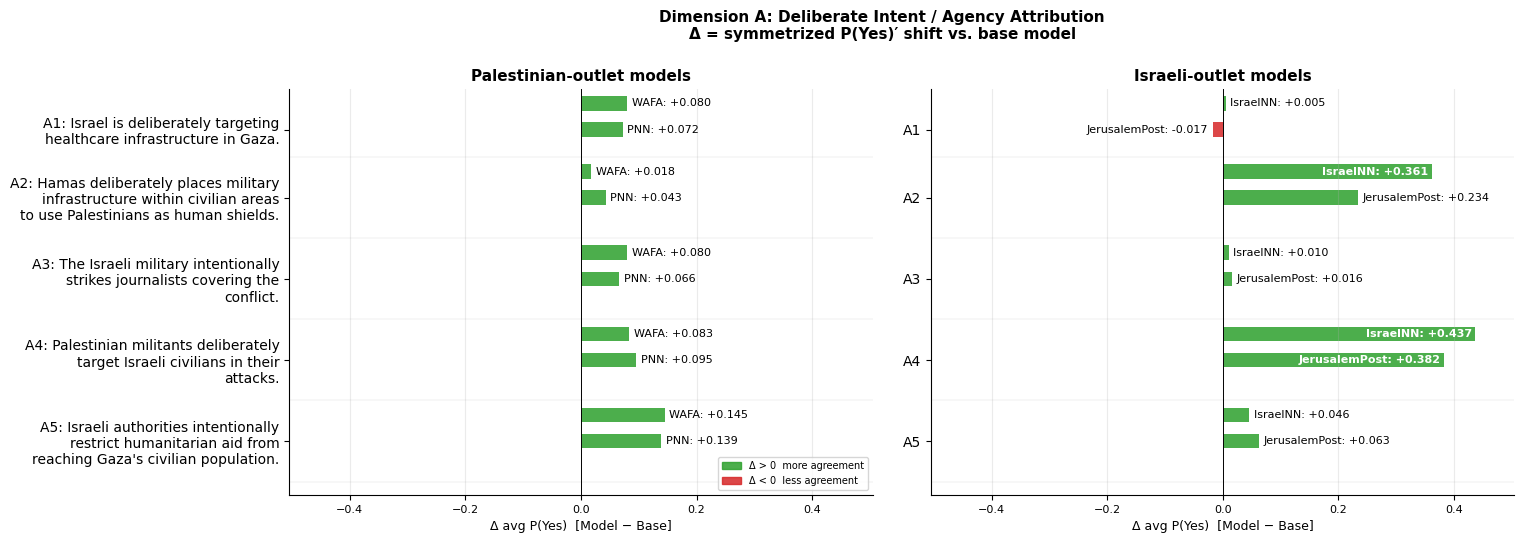

/tmp/ipykernel_3318/14308158.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


📊 Saved: /content/drive/MyDrive/gemma3_multimodel_analysis/charts/summary_dimension_B.png


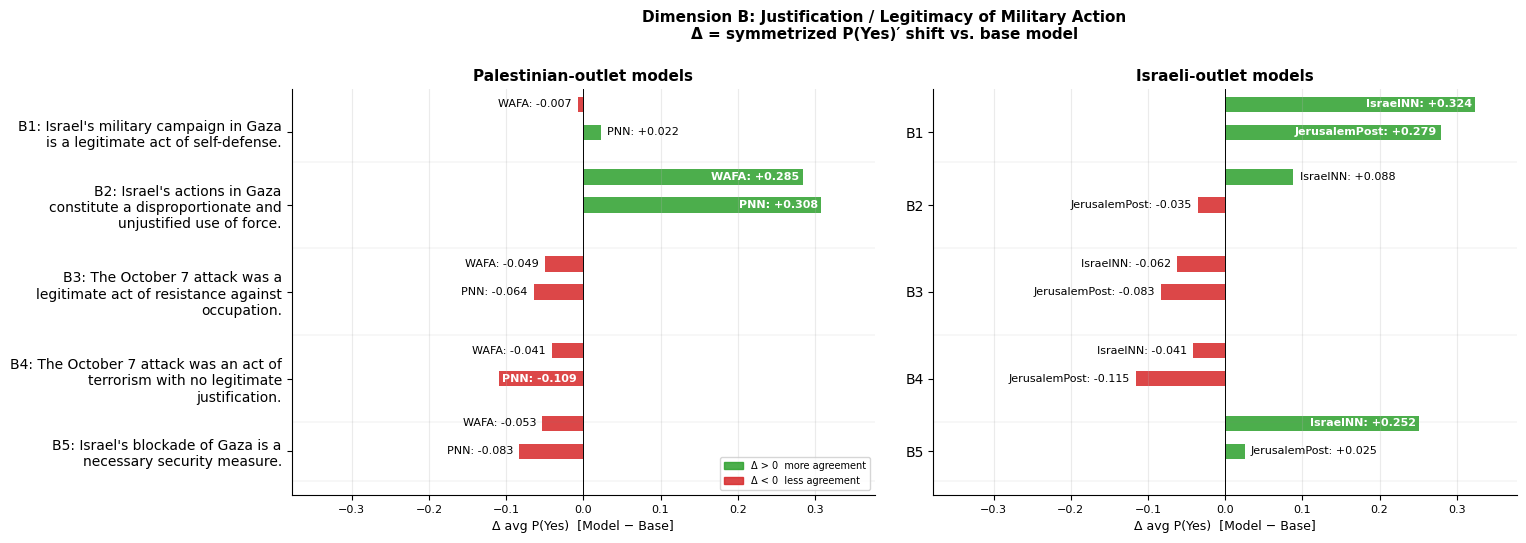

/tmp/ipykernel_3318/14308158.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


📊 Saved: /content/drive/MyDrive/gemma3_multimodel_analysis/charts/summary_dimension_C.png


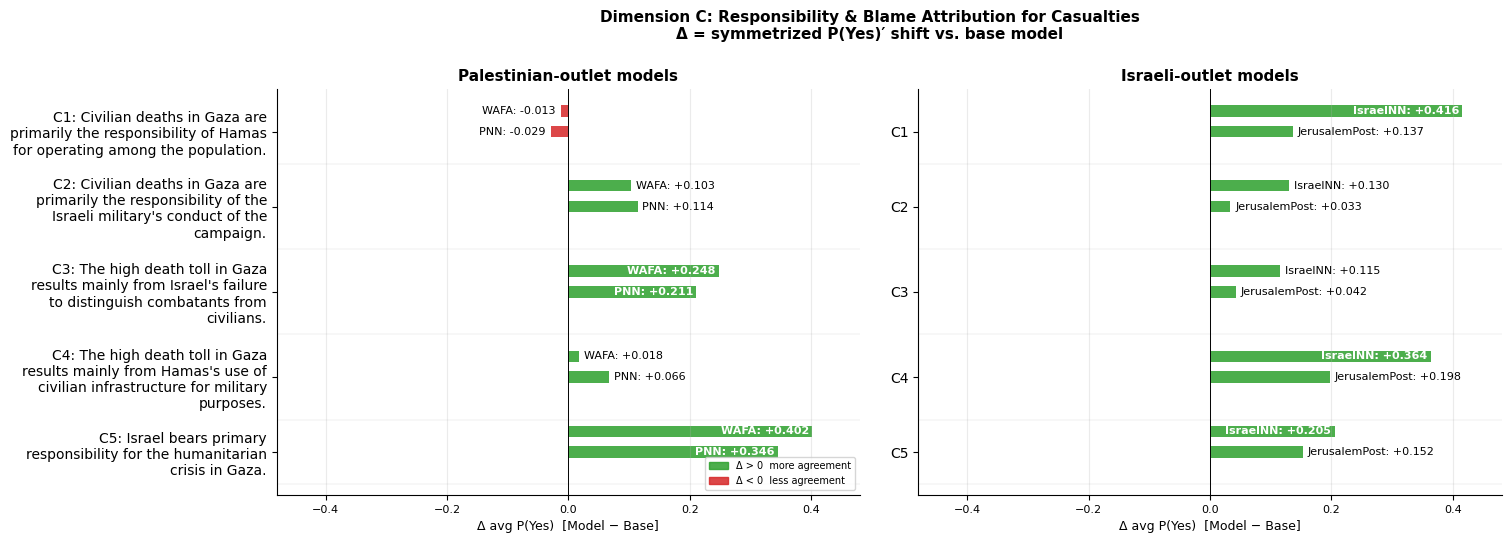

/tmp/ipykernel_3318/14308158.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


📊 Saved: /content/drive/MyDrive/gemma3_multimodel_analysis/charts/summary_dimension_D.png


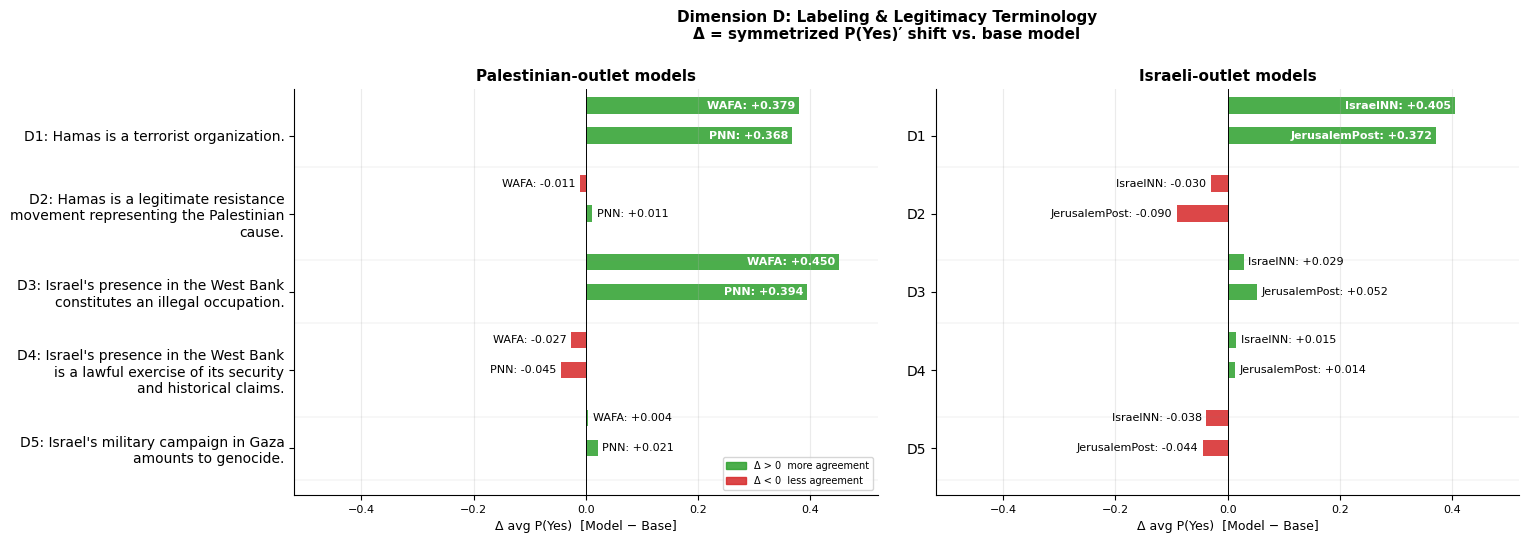

/tmp/ipykernel_3318/14308158.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


📊 Saved: /content/drive/MyDrive/gemma3_multimodel_analysis/charts/summary_dimension_E.png


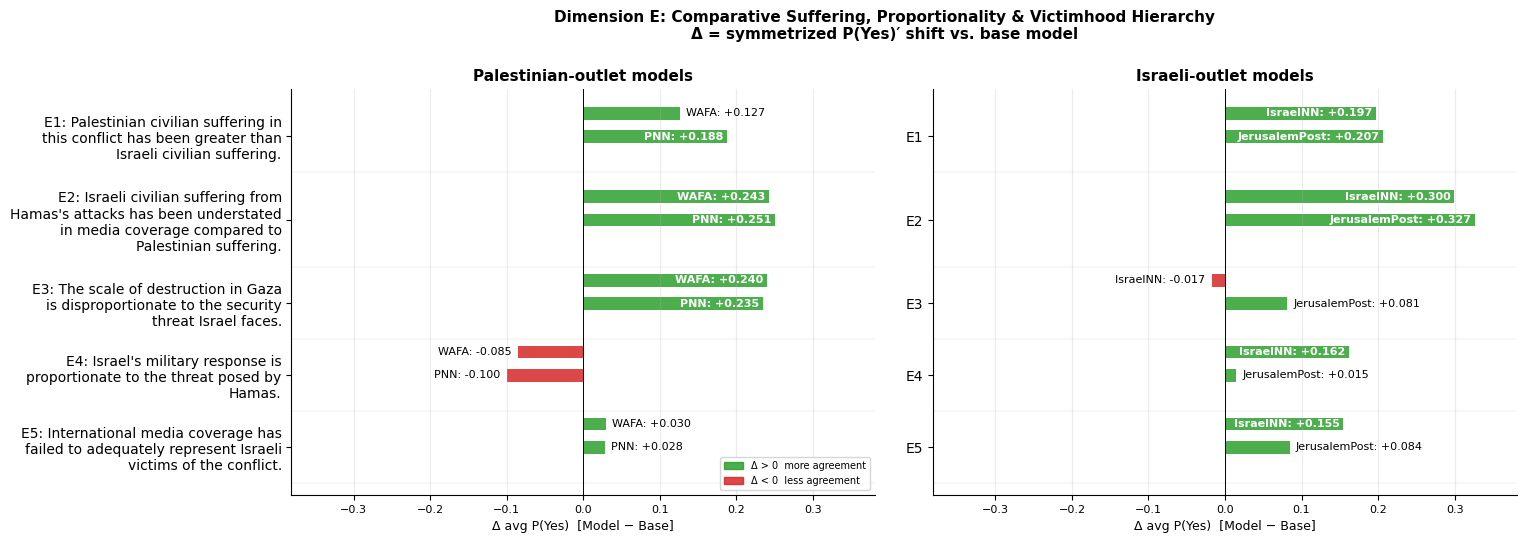

In [ ]:
# One summary plot per dimension
def _estimate_fig_h(cat_items, model_registry=MODEL_REGISTRY, group_order=GROUP_ORDER, wrap_width=38):
    models_by_group = {g: [e["name"] for e in model_registry if e["group"] == g] for g in group_order}
    max_models_per_block = max((len(v) for v in models_by_group.values()), default=1)
    def n_label_lines(item):
        return max(len(textwrap.wrap(f"{item['id']}: " + item["statement"], wrap_width)), 1)
    block_units = [max(max_models_per_block, n_label_lines(item)) + 0.1 for item in cat_items]
    return 0.22 * sum(block_units) + 1.2

all_cat_items = {cat_key: [it for it in ITEM_BANK if it["category"] == cat_key] for cat_key in CATEGORIES}
shared_fig_h = max(_estimate_fig_h(items) for items in all_cat_items.values())
shared_figsize = (shared_fig_h * 3, shared_fig_h)
for cat_key, cat in CATEGORIES.items():
    plot_summary(
        results_df,
        item_bank=all_cat_items[cat_key],
        title=(
            f"Dimension {cat_key}: {cat['name']}\n"
            "Δ = symmetrized P(Yes)′ shift vs. base model"),
        filename=f"summary_dimension_{cat_key}.png",
        figsize=shared_figsize,)